In [76]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd #Permite mostrar tablas como si fuesen de excel
import seaborn as sns

<h1>Exploratory data analysis (EDA)</h1>

https://jse.amstat.org/v19n3/decock.pdf

https://jse.amstat.org/v19n3/decock/DataDocumentation.txt

- **Overall Qual:** Rating for the overall material and finish of the house on a scale from 1 (very poor) to 10 (excellent)
- **Overall Cond:** Rating for the overall condition of the house on a scale from 1 (very poor) to 10 (excellent)
- **Gr Liv Area:** Above grade (ground) living area in square feet
- **Central Air:** Cental air conditioning (N=no, Y=yes)
- **Total Bsmt SF:** Total square feet of the basement area
- **SalePrice:** Sale price in U.S. dollars ($)

In [77]:
columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area', 'Central Air', 'Total Bsmt SF', 'SalePrice']

In [78]:
df = pd.read_csv('AmesHousing.txt', sep='\t', usecols=columns)

In [79]:
df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [80]:
df.shape

(2930, 6)

In [81]:
df['Central Air'] = df['Central Air'].map({'N':0, 'Y':1})

In [82]:
df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,1,1656,215000
1,5,6,882.0,1,896,105000
2,6,6,1329.0,1,1329,172000
3,7,5,2110.0,1,2110,244000
4,5,5,928.0,1,1629,189900


In [83]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [84]:
df = df.dropna(axis=0) #dropna elimina los nulos; axis=0 elimina la fila

In [85]:
df.shape

(2929, 6)

In [86]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

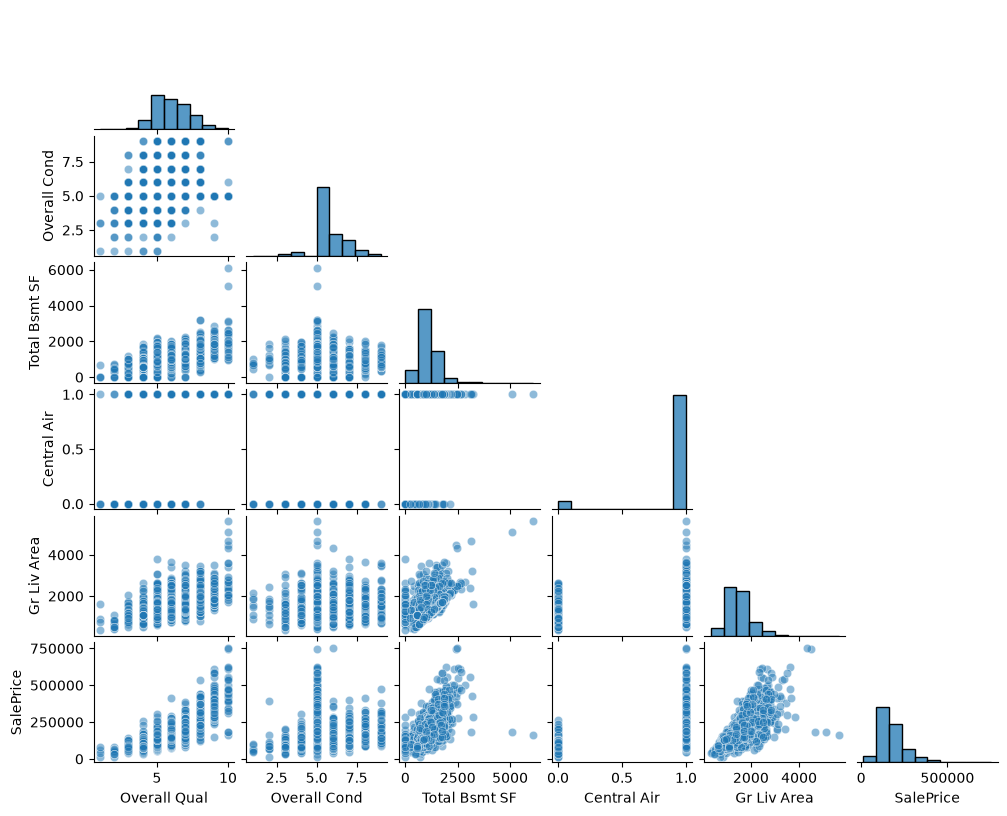

In [87]:
sns.pairplot(df, corner=True, plot_kws={'alpha':0.5}, diag_kws={'bins':10, 'stat':'count'})
plt.gcf().set_size_inches(10, 8)
plt.tight_layout
plt.show()

In [88]:
df.corr() #Lo mismo que se ve en la gráfica, pero muestra la correlación de manera numérica

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
Overall Qual,1.000000,-0.094219,0.547294,0.287443,0.570304,0.799138
Overall Cond,-0.094219,1.000000,-0.173344,0.119611,-0.115176,-0.101191
Total Bsmt SF,0.547294,-0.173344,1.000000,0.218726,0.444675,0.632280
Central Air,0.287443,0.119611,0.218726,1.000000,0.123358,0.264700
Gr Liv Area,0.570304,-0.115176,0.444675,0.123358,1.000000,0.706628
SalePrice,0.799138,-0.101191,0.632280,0.264700,0.706628,1.000000


<p>Gran correlación nos ayuda a identificar las dependientes y una baja las independientes</p>

<Axes: >

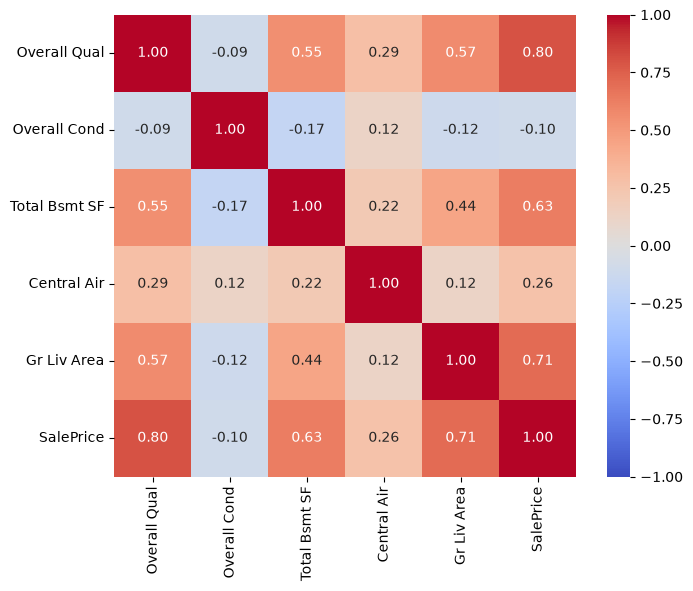

In [89]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, fmt='.2f', square=True, vmin=-1.0, vmax=1.0)

<h1>Simple Linear Regression</h1>

In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import add_dummy_feature

In [91]:
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values[:, np.newaxis]

In [92]:
y

array([[215000],
       [105000],
       [172000],
       ...,
       [132000],
       [170000],
       [188000]], shape=(2929, 1))

In [93]:
sc_x = StandardScaler()  #Esto es parte de la tarea, el QUÉ es el escalamiento
sc_y = StandardScaler()

X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y)

In [94]:
m = X.shape[0]
eta = 0.1
n_epochs = 500

In [95]:
rng = np.random.default_rng(seed=42)

In [96]:
theta = rng.standard_normal((2, 1))
theta

array([[ 0.30471708],
       [-1.03998411]])

In [97]:
X_b = add_dummy_feature(X_std)

In [98]:
J_log = np.zeros(n_epochs)

for i in range(n_epochs):
    J_log[i] = (1/(m))*((X_b@theta-y_std)**2).sum()
    
    gradients = 2/m * X_b.T @ (X_b@theta - y_std)
    theta = theta - eta * gradients

theta

array([[-1.39011669e-16],
       [ 7.06628223e-01]])

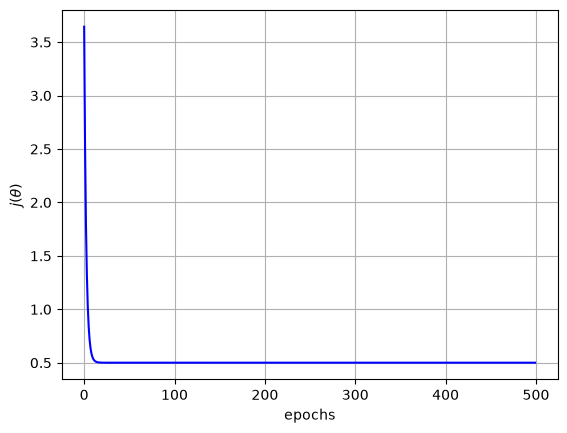

In [99]:
plt.plot(np.arange(n_epochs), J_log, 'b-')
plt.xlabel('epochs')
plt.ylabel(r'$j(\theta)$')
plt.grid(True)
plt.show()

In [101]:
X_new = np.array([[X.min()], [X.max()]])
X_new_std = sc_x.transform(X_new)
X_new_b = add_dummy_feature(X_new_std)

y_predict_std = X_new_b @ theta
y_predict = sc_y.inverse_transform(y_predict_std)
y_predict

array([[ 50639.50897509],
       [643364.00867569]])